In [1]:
import itertools as it

import boto3
import botocore
from cliffs_delta import cliffs_delta
from matplotlib import pyplot as plt
import matplotlib.lines as mlines
import numpy as np
import pandas as pd
from pandas.util import hash_pandas_object
import pingouin as pg
from scipy import stats as scipy_stats
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
import statsmodels.genmod.cov_struct as cov_structs
from teeplot import teeplot as tp


In [2]:
from dishpylib.pyhelpers import make_outattr_metadata
from dishpylib.pyhelpers import print_runtime


In [3]:
print_runtime()


context: ci
hostname: runnervmwvtoz
interpreter: 3.10.12 (main, Aug 31 2026, 10:18:17) [GCC 11.4.0]
notebook name: 2026-10-10-nicheconst-complexitystability-9s
notebook path: /home/runner/work/oee4/oee4/binder/2026-10-10-nicheconst-complexitystability-9s.ipynb
revision: bdac574
timestamp: 2026-10-11T23:41:21Z00:00

IPython==7.16.1
packaging==26.2


<ipython-input-3-4d790cf6450f>:1: DeprecatedWarning: print_runtime is deprecated. use nbmetalog package instead
  print_runtime()


In [4]:
teeplot_subdir = "2026-10-10-nicheconst-complexitystability-9s"


# get data


In [5]:
s3_handle = boto3.resource(
    's3',
    region_name="us-east-2",
    config=botocore.config.Config(
        signature_version=botocore.UNSIGNED,
    ),
)
bucket_handle = s3_handle.Bucket('prq49')

series_profiles, = bucket_handle.objects.filter(
    Prefix=f'endeavor=16/series-profiles/stage=8+what=elaborated/',
)


/usr/local/lib/python3.10/dist-packages/outdated/utils.py:14: OutdatedPackageWarning: The package pingouin is out of date. Your version is 0.5.3, the latest is 0.7.0.
Set the environment variable OUTDATED_IGNORE=1 to disable these warnings.
  return warn(


In [6]:
df = pd.read_csv(
    f's3://prq49/{series_profiles.key}',
    compression='xz',
)
dfdigest = '{:x}'.format( hash_pandas_object( df ).sum() )
dfdigest


<ipython-input-6-747b1fe91af5>:1: DtypeWarning: Columns (286,293,300,301,302,303,305,306,307,308,314,315,316,317,318,324,325,326) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(


'-333308f100cbd3f8'

In [7]:
def make_outattr_metadata():
    return {}


In [8]:
for stint in df['Stint'].unique():
    exec(f'df{stint} = df[ df["Stint"] == {stint} ]')


In [9]:
df["m10"] = df["Stint"] % 10
dfm10 = df[ df["m10"].isin([0, 9]) ]


In [10]:
s3_handle = boto3.resource(
    "s3",
    region_name="us-east-2",
    config=botocore.config.Config(
        signature_version=botocore.UNSIGNED,
    ),
)
bucket_handle = s3_handle.Bucket("prq49")

dfnone = pd.concat(
    [
        pd.read_csv(f"s3://prq49/{item.key}")
        for item in bucket_handle.objects.filter(
            Prefix=f"endeavor=16/external-competitions/stage=2+what=collated/",
        )
    ],
    ignore_index=True,
)
dfnone["kind"] = "none"
print(dfnone["Competition Stint"].unique())
print(dfnone["Competition Series"].unique())


[  1  10 100  11  12  13  14  15  16  17  18  19   2  20  21  22  23  24
  25  26  27  28  29   3  30  31  32  33  34  35  36  37  38  39   4  40
  41  42  43  44  45  46  47  48  49   5  50  51  52  53  54  55  56  57
  58  59   6  60  61  62  63  64  65  66  67  68  69   7  70  71  72  73
  74  75  76  77  78  79   8  80  81  82  83  84  85  86  87  88  89   9
  90  91  92  93  94  95  96  97  98  99]
[16005 16000 16001 16002 16003 16004 16006 16007 16008 16009 16010 16011
 16012 16013 16014 16015 16016 16017 16018 16019 16020 16021 16022 16023
 16024 16025 16026 16027 16028 16029 16030 16031 16032 16033 16034 16035
 16036 16037 16038 16039]


In [11]:
s3_handle = boto3.resource(
    "s3",
    region_name="us-east-2",
    config=botocore.config.Config(
        signature_version=botocore.UNSIGNED,
    ),
)
bucket_handle = s3_handle.Bucket("prq49")

dfbio = pd.concat(
    [
        pd.read_csv(f"s3://prq49/{item.key}")
        for item in bucket_handle.objects.filter(
            Prefix=f"endeavor=16/external-competitions-focalbb-true/stage=2+what=collated/",
        )
    ],
    ignore_index=True,
)
dfbio["kind"] = "eco"
print(dfbio["Competition Stint"].unique())
print(dfbio["Competition Series"].unique())


[ 10 100  11  12  13  14  15  16  17  18  19   2  20  21  22  23  24  25
  26  27  28  29   3  30  31  32  33  34  35  36  37  38  39   4  40  41
  42  43  44  45  46  47  48  49   5  50  51  52  53  54  55  56  57  58
  59   6  60  61  62  63  64  65  66  67  68  69   7  70  71  72  73  74
  75  76  77  78  79   8  80  81  82  83  84  85  86  87  88  89   9  90
  91  92  93  94  95  96  97  98  99]
[16000 16001 16002 16003 16004 16005 16006 16007 16008 16009 16010 16011
 16012 16013 16014 16015 16016 16017 16018 16019 16020 16021 16022 16023
 16024 16025 16026 16027 16028 16029 16030 16031 16032 16033 16034 16035
 16036 16037 16038 16039]


In [12]:
s3_handle = boto3.resource(
    "s3",
    region_name="us-east-2",
    config=botocore.config.Config(
        signature_version=botocore.UNSIGNED,
    ),
)
bucket_handle = s3_handle.Bucket("prq49")

dfabio = pd.concat(
    [
        pd.read_csv(f"s3://prq49/{item.key}")
        for item in bucket_handle.objects.filter(
            Prefix=f"endeavor=16/external-competitions-focalbb/stage=2+what=collated/",
        )
    ],
    ignore_index=True,
)
dfabio["kind"] = "self"
print(dfabio["Competition Stint"].unique())
print(dfabio["Competition Series"].unique())


[  1  10 100  11  12  13  14  15  16  17  18  19   2  20  21  22  23  24
  25  26  27  28  29   3  30  31  32  33  34  35  36  37  38  39   4  40
  41  42  43  44  45  46  47  48  49   5  50  51  52  53  54  55  56  57
  58  59   6  60  61  62  63  64  65  66  67  68  69   7  70  71  72  73
  74  75  76  77  78  79   8  80  81  82  83  84  85  86  87  88  89   9
  90  91  92  93  94  95  96  97  98  99]
[16005 16000 16001 16002 16003 16004 16006 16007 16008 16009 16010 16011
 16012 16013 16014 16015 16016 16017 16018 16019 16020 16021 16022 16023
 16024 16025 16026 16027 16028 16029 16030 16031 16032 16033 16034 16035
 16036 16037 16038 16039]


In [13]:
dfx = pd.concat([dfabio, dfbio, dfnone], ignore_index=True)
dfx["Fitness Differential Focal Sign"] = np.sign(
    dfx["Fitness Differential Focal"],
)
dfx["Series"] = dfx["Competition Series"]
dfx["Stint"] = dfx["Competition Stint"]
dfx["flip series"] = dfx["genome series"] * (dfx["Root ID"] == 1)
dfx["Competitor"] = (
    dfx
    .groupby(["Stint", "Series", "kind", "Competition Repro"])
    ["flip series"]
    .transform("max")
)
dfx = dfx[
    dfx["Root ID"] == 0
].groupby(["Stint", "Series", "kind", "Competitor"])[
    "Focal Prevalence"
].mean().round().reset_index(drop=False)
dfx


,Stint,Series,kind,Competitor,Focal Prevalence
0,1,16005,none,16000.0,1.0
1,1,16005,none,16001.0,0.0
2,1,16005,none,16002.0,0.0
3,1,16005,none,16003.0,0.0
4,1,16005,none,16004.0,0.0
...,...,...,...,...,...
105517,100,16039,self,16035.0,0.0
105518,100,16039,self,16036.0,1.0
105519,100,16039,self,16037.0,0.0
105520,100,16039,self,16038.0,0.0


In [14]:
dfj = dfx.join(
    dfm10[
        [
            "Stint",
            "Series",
            "Fitness Complexity",
            "Flagged Advantageous Sites",
            "Flagged Deleterious Sites",
            "Cardinal Interface Complexity",
            "Cell Interface Complexity",
        ]
    ].set_index(
        ["Stint", "Series"]
    ),
    on=["Stint", "Series"],
    how="inner",
).reset_index(drop=False)
dfj["Favored"] = dfj["Focal Prevalence"] > 0.5
dfj


,index,Stint,Series,kind,Competitor,Focal Prevalence,Fitness Complexity,Flagged Advantageous Sites,Flagged Deleterious Sites,Cardinal Interface Complexity,Cell Interface Complexity,Favored
0,920,9,16000,eco,16000.0,0.0,12.37,13.0,5.0,3.0,2.0,False
1,921,9,16000,eco,16001.0,0.0,12.37,13.0,5.0,3.0,2.0,False
2,922,9,16000,eco,16002.0,0.0,12.37,13.0,5.0,3.0,2.0,False
3,923,9,16000,eco,16003.0,0.0,12.37,13.0,5.0,3.0,2.0,False
4,924,9,16000,eco,16004.0,0.0,12.37,13.0,5.0,3.0,2.0,False
...,...,...,...,...,...,...,...,...,...,...,...,...
95957,105517,100,16039,self,16035.0,0.0,14.67,17.0,0.0,2.0,2.0,False
95958,105518,100,16039,self,16036.0,1.0,14.67,17.0,0.0,2.0,2.0,True
95959,105519,100,16039,self,16037.0,0.0,14.67,17.0,0.0,2.0,2.0,False
95960,105520,100,16039,self,16038.0,0.0,14.67,17.0,0.0,2.0,2.0,False


In [15]:
lpal = {
    "co-evo": "#a3cf73",
    "self": "#5caf96",
    "none": "#f2dfae",
    "Bkgd.": "#ffffff",
}


## Visualization


how='Mean'
n Series: 40  n rows: 800
['none', 'self']
Categories (2, object): ['none', 'self']
teeplots/how=mean+hue=when+viz=boxplot+x=sas+y=je+ext=.pdf
teeplots/how=mean+hue=when+viz=boxplot+x=sas+y=je+ext=.png


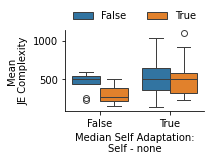

how='Median'
n Series: 40  n rows: 800
['none', 'self']
Categories (2, object): ['none', 'self']
teeplots/how=median+hue=when+viz=boxplot+x=sas+y=je+ext=.pdf
teeplots/how=median+hue=when+viz=boxplot+x=sas+y=je+ext=.png


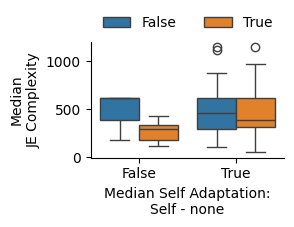

how='Peak'
n Series: 40  n rows: 800
['none', 'self']
Categories (2, object): ['none', 'self']
teeplots/how=peak+hue=when+viz=boxplot+x=sas+y=je+ext=.pdf
teeplots/how=peak+hue=when+viz=boxplot+x=sas+y=je+ext=.png


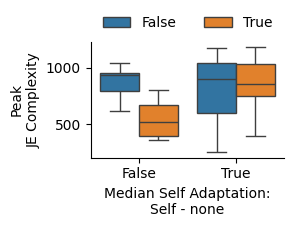

how='Trimmed Peak'
n Series: 40  n rows: 800
['none', 'self']
Categories (2, object): ['none', 'self']
teeplots/how=trimmed-peak+hue=when+viz=boxplot+x=sas+y=je+ext=.pdf
teeplots/how=trimmed-peak+hue=when+viz=boxplot+x=sas+y=je+ext=.png


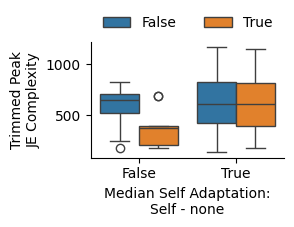

In [16]:
for other in ["none"]:
    for how, how_func in {
        "Mean": lambda x: x.mean(),
        "Median": lambda x: x.median(),
        "Peak": lambda x: x.nlargest(1).min(),
        "Trimmed Peak": lambda x: x.nlargest(2).min(),
    }.items():
        if other == "co-evo":
            other = "eco"
        print(f"{how=}")
        dfjx = dfj.reset_index(
            drop=False,
        )

        data = dfjx[
            dfjx["Stint"].isin(range(9, 101, 10))
        ].groupby(
            ["Stint", "Series", "kind"]
        ).mean().reset_index()

        data["cic rank"] = data["Cardinal Interface Complexity"].rank()
        data["fas rank"] = data["Flagged Advantageous Sites"].rank()
        data["je"] = data[["cic rank", "fas rank"]].min(axis=1)

        d = data[
            data["kind"].isin(["self", other])
        ].copy().replace({"eco": "co-evo"}).copy()
        if other == "eco":
            other = "co-evo"
        d["kind"] = pd.Categorical(
            d["kind"],
            categories=[other, "self"],
        )

        print("n Series:", d["Series"].nunique(), " n rows:", len(d))
        print(d["kind"].unique())
        d["when"] = d["Stint"] > 50

        dd = d.pivot_table(
            index=["Series", "Cardinal Interface Complexity", "Flagged Advantageous Sites", "je", "when"],
            columns=["kind"],
            values=["Focal Prevalence"],
        ).reset_index()
        dd["Self Adaptation"] = dd["Focal Prevalence"]["self"] - dd["Focal Prevalence"][other]

        dd = dd.groupby(
            ["Series", "when"]
        ).agg(
            {
                ("Cardinal Interface Complexity", ""): how_func,
                ("Flagged Advantageous Sites", ""): how_func,
                ("je", ""):  how_func,
                ("Self Adaptation", ""): np.median,
            },
        ).reset_index()

        dd["sas"] = dd["Self Adaptation"] > dd["Self Adaptation"].quantile(0.2)

        for what in [
            "je",
            # "Flagged Advantageous Sites",
            # "Cardinal Interface Complexity",
        ]:
            with tp.teed(
                sns.boxplot,
                data=dd,
                x="sas",
                y=what,
                hue="when",
                # scatter_kws=dict(s=5, color="k", zorder=3),
                teeplot_outattrs={"how": how.lower().replace(" ", "-")},
            ) as ax:
                sns.despine(ax=ax)
                ax.figure.set_size_inches(3, 2)
                ax.set_xlabel(f"Median Self Adaptation:\nSelf - {other}")
                word = {
                    "Flagged Advantageous Sites": "G",
                    "Cardinal Interface Complexity": "P",
                    "je": "JE",
                }[what]
                ax.set_ylabel(f"{how}\n{word} Complexity")
                sns.move_legend(
                    ax, "lower center",
                    bbox_to_anchor=(.5, 1), ncol=2, title=None, frameon=False,
                )
                # spear_r, spear_p = scipy_stats.spearmanr(
                #     dd["Self Adaptation"],
                #     dd[what],
                # )
                # pear_r, pear_p = scipy_stats.pearsonr(
                #     dd["Self Adaptation"],
                #     dd[what],
                # )

                # # Format the annotation string
                # stats_text = (
                #     fr"$r={pear_r:.2f},\rho={spear_r:.2f}$"
                #     + f"\n$p={pear_p:.3f},{spear_p:.3f}$"
                # )
                # print(stats_text)

                ax.figure.set_size_inches(2.5, 1.5)
                # ax.text(-0.38, -0.1, stats_text,
                #         transform=ax.transAxes,
                #         fontsize=5.5,
                #         verticalalignment='top',
                #         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
                # )
                # # ax.set_ylim(0, None)


when='all' how='Mean'
n Series: 40  n rows: 800
['none', 'self']
Categories (2, object): ['none', 'self']
$r=0.47,\rho=0.37$
$p=0.002,0.018$
teeplots/how=mean+viz=regplot+when=all+x=self-adaptation+y=je+ext=.pdf
teeplots/how=mean+viz=regplot+when=all+x=self-adaptation+y=je+ext=.png


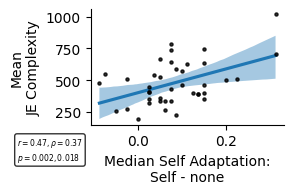

$r=0.31,\rho=0.36$
$p=0.048,0.023$
teeplots/how=mean+viz=regplot+when=all+x=self-adaptation+y=flagged-advantageous-sites+ext=.pdf
teeplots/how=mean+viz=regplot+when=all+x=self-adaptation+y=flagged-advantageous-sites+ext=.png


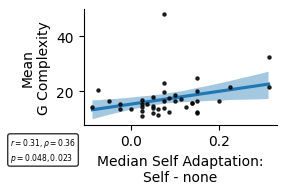

$r=0.56,\rho=0.39$
$p=0.000,0.013$
teeplots/how=mean+viz=regplot+when=all+x=self-adaptation+y=cardinal-interface-complexity+ext=.pdf
teeplots/how=mean+viz=regplot+when=all+x=self-adaptation+y=cardinal-interface-complexity+ext=.png


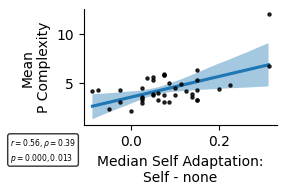

when='all' how='Median'
n Series: 40  n rows: 800
['none', 'self']
Categories (2, object): ['none', 'self']
$r=0.43,\rho=0.34$
$p=0.006,0.031$
teeplots/how=median+viz=regplot+when=all+x=self-adaptation+y=je+ext=.pdf
teeplots/how=median+viz=regplot+when=all+x=self-adaptation+y=je+ext=.png


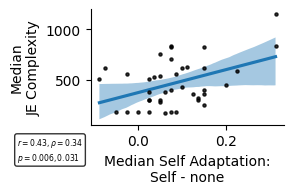

$r=0.42,\rho=0.29$
$p=0.007,0.069$
teeplots/how=median+viz=regplot+when=all+x=self-adaptation+y=flagged-advantageous-sites+ext=.pdf
teeplots/how=median+viz=regplot+when=all+x=self-adaptation+y=flagged-advantageous-sites+ext=.png


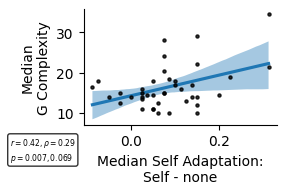

$r=0.49,\rho=0.29$
$p=0.001,0.073$
teeplots/how=median+viz=regplot+when=all+x=self-adaptation+y=cardinal-interface-complexity+ext=.pdf
teeplots/how=median+viz=regplot+when=all+x=self-adaptation+y=cardinal-interface-complexity+ext=.png


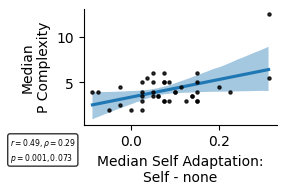

when='all' how='Peak'
n Series: 40  n rows: 800
['none', 'self']
Categories (2, object): ['none', 'self']
$r=0.49,\rho=0.48$
$p=0.001,0.002$
teeplots/how=peak+viz=regplot+when=all+x=self-adaptation+y=je+ext=.pdf
teeplots/how=peak+viz=regplot+when=all+x=self-adaptation+y=je+ext=.png


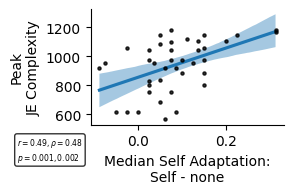

$r=0.08,\rho=0.35$
$p=0.638,0.029$
teeplots/how=peak+viz=regplot+when=all+x=self-adaptation+y=flagged-advantageous-sites+ext=.pdf
teeplots/how=peak+viz=regplot+when=all+x=self-adaptation+y=flagged-advantageous-sites+ext=.png


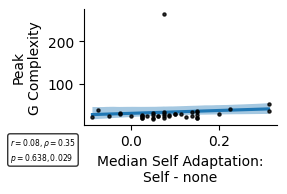

$r=0.50,\rho=0.37$
$p=0.001,0.017$
teeplots/how=peak+viz=regplot+when=all+x=self-adaptation+y=cardinal-interface-complexity+ext=.pdf
teeplots/how=peak+viz=regplot+when=all+x=self-adaptation+y=cardinal-interface-complexity+ext=.png


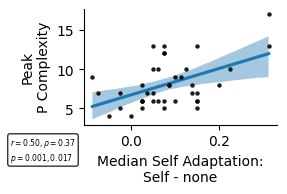

when='all' how='Trimmed Peak'
n Series: 40  n rows: 800
['none', 'self']
Categories (2, object): ['none', 'self']
$r=0.51,\rho=0.51$
$p=0.001,0.001$
teeplots/how=trimmed-peak+viz=regplot+when=all+x=self-adaptation+y=je+ext=.pdf
teeplots/how=trimmed-peak+viz=regplot+when=all+x=self-adaptation+y=je+ext=.png


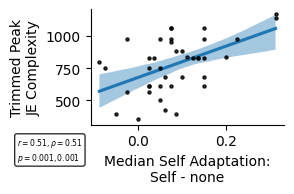

$r=0.56,\rho=0.43$
$p=0.000,0.005$
teeplots/how=trimmed-peak+viz=regplot+when=all+x=self-adaptation+y=flagged-advantageous-sites+ext=.pdf
teeplots/how=trimmed-peak+viz=regplot+when=all+x=self-adaptation+y=flagged-advantageous-sites+ext=.png


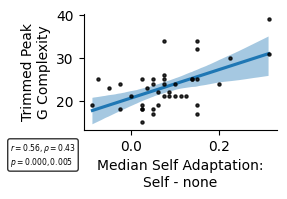

$r=0.68,\rho=0.53$
$p=0.000,0.000$
teeplots/how=trimmed-peak+viz=regplot+when=all+x=self-adaptation+y=cardinal-interface-complexity+ext=.pdf
teeplots/how=trimmed-peak+viz=regplot+when=all+x=self-adaptation+y=cardinal-interface-complexity+ext=.png


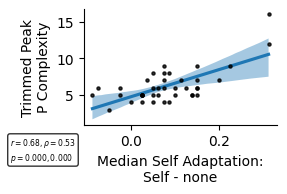

when='all' how='Mean'
n Series: 40  n rows: 800
['co-evo', 'self']
Categories (2, object): ['co-evo', 'self']
$r=0.37,\rho=0.29$
$p=0.017,0.072$
teeplots/how=mean+viz=regplot+when=all+x=self-adaptation+y=je+ext=.pdf
teeplots/how=mean+viz=regplot+when=all+x=self-adaptation+y=je+ext=.png


/usr/local/lib/python3.10/dist-packages/teeplot/teeplot.py:324: UserWarning: teeplot already created file teeplots/how=mean+viz=regplot+when=all+x=self-adaptation+y=je+ext=.pdf, overwriting it
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/teeplot/teeplot.py:324: UserWarning: teeplot already created file teeplots/how=mean+viz=regplot+when=all+x=self-adaptation+y=je+ext=.png, overwriting it
  warnings.warn(


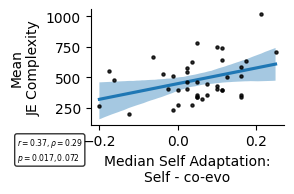

$r=0.23,\rho=0.35$
$p=0.146,0.028$
teeplots/how=mean+viz=regplot+when=all+x=self-adaptation+y=flagged-advantageous-sites+ext=.pdf
teeplots/how=mean+viz=regplot+when=all+x=self-adaptation+y=flagged-advantageous-sites+ext=.png


/usr/local/lib/python3.10/dist-packages/teeplot/teeplot.py:324: UserWarning: teeplot already created file teeplots/how=mean+viz=regplot+when=all+x=self-adaptation+y=flagged-advantageous-sites+ext=.pdf, overwriting it
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/teeplot/teeplot.py:324: UserWarning: teeplot already created file teeplots/how=mean+viz=regplot+when=all+x=self-adaptation+y=flagged-advantageous-sites+ext=.png, overwriting it
  warnings.warn(


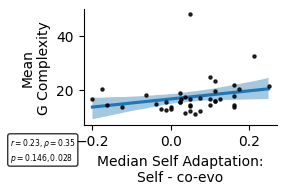

$r=0.41,\rho=0.31$
$p=0.008,0.051$
teeplots/how=mean+viz=regplot+when=all+x=self-adaptation+y=cardinal-interface-complexity+ext=.pdf
teeplots/how=mean+viz=regplot+when=all+x=self-adaptation+y=cardinal-interface-complexity+ext=.png


/usr/local/lib/python3.10/dist-packages/teeplot/teeplot.py:324: UserWarning: teeplot already created file teeplots/how=mean+viz=regplot+when=all+x=self-adaptation+y=cardinal-interface-complexity+ext=.pdf, overwriting it
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/teeplot/teeplot.py:324: UserWarning: teeplot already created file teeplots/how=mean+viz=regplot+when=all+x=self-adaptation+y=cardinal-interface-complexity+ext=.png, overwriting it
  warnings.warn(


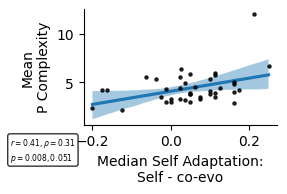

when='all' how='Median'
n Series: 40  n rows: 800
['co-evo', 'self']
Categories (2, object): ['co-evo', 'self']
$r=0.32,\rho=0.28$
$p=0.042,0.081$
teeplots/how=median+viz=regplot+when=all+x=self-adaptation+y=je+ext=.pdf
teeplots/how=median+viz=regplot+when=all+x=self-adaptation+y=je+ext=.png


/usr/local/lib/python3.10/dist-packages/teeplot/teeplot.py:324: UserWarning: teeplot already created file teeplots/how=median+viz=regplot+when=all+x=self-adaptation+y=je+ext=.pdf, overwriting it
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/teeplot/teeplot.py:324: UserWarning: teeplot already created file teeplots/how=median+viz=regplot+when=all+x=self-adaptation+y=je+ext=.png, overwriting it
  warnings.warn(


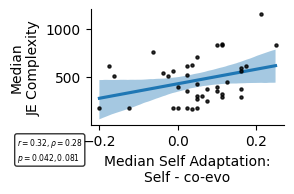

$r=0.33,\rho=0.30$
$p=0.038,0.057$
teeplots/how=median+viz=regplot+when=all+x=self-adaptation+y=flagged-advantageous-sites+ext=.pdf
teeplots/how=median+viz=regplot+when=all+x=self-adaptation+y=flagged-advantageous-sites+ext=.png


/usr/local/lib/python3.10/dist-packages/teeplot/teeplot.py:324: UserWarning: teeplot already created file teeplots/how=median+viz=regplot+when=all+x=self-adaptation+y=flagged-advantageous-sites+ext=.pdf, overwriting it
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/teeplot/teeplot.py:324: UserWarning: teeplot already created file teeplots/how=median+viz=regplot+when=all+x=self-adaptation+y=flagged-advantageous-sites+ext=.png, overwriting it
  warnings.warn(


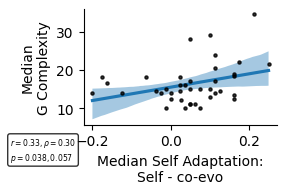

$r=0.36,\rho=0.24$
$p=0.022,0.136$
teeplots/how=median+viz=regplot+when=all+x=self-adaptation+y=cardinal-interface-complexity+ext=.pdf
teeplots/how=median+viz=regplot+when=all+x=self-adaptation+y=cardinal-interface-complexity+ext=.png


/usr/local/lib/python3.10/dist-packages/teeplot/teeplot.py:324: UserWarning: teeplot already created file teeplots/how=median+viz=regplot+when=all+x=self-adaptation+y=cardinal-interface-complexity+ext=.pdf, overwriting it
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/teeplot/teeplot.py:324: UserWarning: teeplot already created file teeplots/how=median+viz=regplot+when=all+x=self-adaptation+y=cardinal-interface-complexity+ext=.png, overwriting it
  warnings.warn(


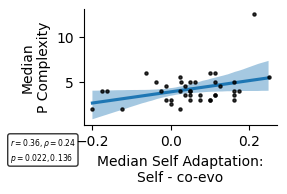

when='all' how='Peak'
n Series: 40  n rows: 800
['co-evo', 'self']
Categories (2, object): ['co-evo', 'self']
$r=0.42,\rho=0.44$
$p=0.007,0.004$
teeplots/how=peak+viz=regplot+when=all+x=self-adaptation+y=je+ext=.pdf
teeplots/how=peak+viz=regplot+when=all+x=self-adaptation+y=je+ext=.png


/usr/local/lib/python3.10/dist-packages/teeplot/teeplot.py:324: UserWarning: teeplot already created file teeplots/how=peak+viz=regplot+when=all+x=self-adaptation+y=je+ext=.pdf, overwriting it
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/teeplot/teeplot.py:324: UserWarning: teeplot already created file teeplots/how=peak+viz=regplot+when=all+x=self-adaptation+y=je+ext=.png, overwriting it
  warnings.warn(


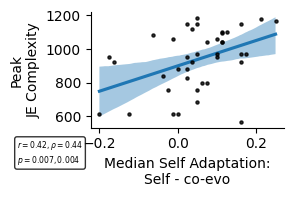

$r=0.06,\rho=0.26$
$p=0.731,0.103$
teeplots/how=peak+viz=regplot+when=all+x=self-adaptation+y=flagged-advantageous-sites+ext=.pdf
teeplots/how=peak+viz=regplot+when=all+x=self-adaptation+y=flagged-advantageous-sites+ext=.png


/usr/local/lib/python3.10/dist-packages/teeplot/teeplot.py:324: UserWarning: teeplot already created file teeplots/how=peak+viz=regplot+when=all+x=self-adaptation+y=flagged-advantageous-sites+ext=.pdf, overwriting it
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/teeplot/teeplot.py:324: UserWarning: teeplot already created file teeplots/how=peak+viz=regplot+when=all+x=self-adaptation+y=flagged-advantageous-sites+ext=.png, overwriting it
  warnings.warn(


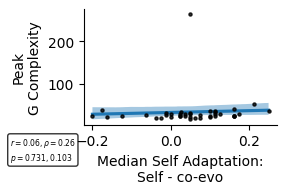

$r=0.41,\rho=0.35$
$p=0.008,0.028$
teeplots/how=peak+viz=regplot+when=all+x=self-adaptation+y=cardinal-interface-complexity+ext=.pdf
teeplots/how=peak+viz=regplot+when=all+x=self-adaptation+y=cardinal-interface-complexity+ext=.png


/usr/local/lib/python3.10/dist-packages/teeplot/teeplot.py:324: UserWarning: teeplot already created file teeplots/how=peak+viz=regplot+when=all+x=self-adaptation+y=cardinal-interface-complexity+ext=.pdf, overwriting it
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/teeplot/teeplot.py:324: UserWarning: teeplot already created file teeplots/how=peak+viz=regplot+when=all+x=self-adaptation+y=cardinal-interface-complexity+ext=.png, overwriting it
  warnings.warn(


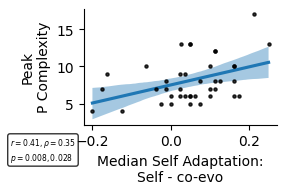

when='all' how='Trimmed Peak'
n Series: 40  n rows: 800
['co-evo', 'self']
Categories (2, object): ['co-evo', 'self']
$r=0.47,\rho=0.46$
$p=0.002,0.003$
teeplots/how=trimmed-peak+viz=regplot+when=all+x=self-adaptation+y=je+ext=.pdf
teeplots/how=trimmed-peak+viz=regplot+when=all+x=self-adaptation+y=je+ext=.png


/usr/local/lib/python3.10/dist-packages/teeplot/teeplot.py:324: UserWarning: teeplot already created file teeplots/how=trimmed-peak+viz=regplot+when=all+x=self-adaptation+y=je+ext=.pdf, overwriting it
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/teeplot/teeplot.py:324: UserWarning: teeplot already created file teeplots/how=trimmed-peak+viz=regplot+when=all+x=self-adaptation+y=je+ext=.png, overwriting it
  warnings.warn(


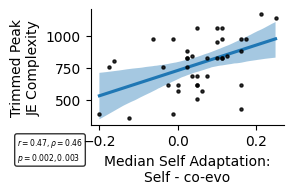

$r=0.36,\rho=0.40$
$p=0.024,0.010$
teeplots/how=trimmed-peak+viz=regplot+when=all+x=self-adaptation+y=flagged-advantageous-sites+ext=.pdf
teeplots/how=trimmed-peak+viz=regplot+when=all+x=self-adaptation+y=flagged-advantageous-sites+ext=.png


/usr/local/lib/python3.10/dist-packages/teeplot/teeplot.py:324: UserWarning: teeplot already created file teeplots/how=trimmed-peak+viz=regplot+when=all+x=self-adaptation+y=flagged-advantageous-sites+ext=.pdf, overwriting it
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/teeplot/teeplot.py:324: UserWarning: teeplot already created file teeplots/how=trimmed-peak+viz=regplot+when=all+x=self-adaptation+y=flagged-advantageous-sites+ext=.png, overwriting it
  warnings.warn(


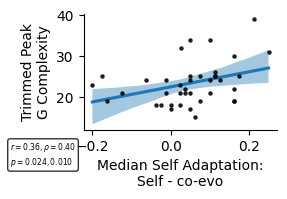

$r=0.49,\rho=0.35$
$p=0.001,0.029$
teeplots/how=trimmed-peak+viz=regplot+when=all+x=self-adaptation+y=cardinal-interface-complexity+ext=.pdf
teeplots/how=trimmed-peak+viz=regplot+when=all+x=self-adaptation+y=cardinal-interface-complexity+ext=.png


/usr/local/lib/python3.10/dist-packages/teeplot/teeplot.py:324: UserWarning: teeplot already created file teeplots/how=trimmed-peak+viz=regplot+when=all+x=self-adaptation+y=cardinal-interface-complexity+ext=.pdf, overwriting it
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/teeplot/teeplot.py:324: UserWarning: teeplot already created file teeplots/how=trimmed-peak+viz=regplot+when=all+x=self-adaptation+y=cardinal-interface-complexity+ext=.png, overwriting it
  warnings.warn(


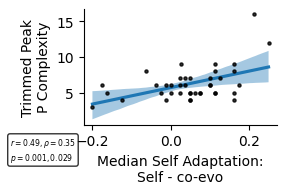

In [17]:
for other in "none", "eco":
    for when, when_range in {
        # "early": range(9, 51, 10),
        # "late": range(59, 101, 10),
        "all": range(9, 101, 10),
    }.items():
        for how, how_func in {
            "Mean": lambda x: x.mean(),
            "Median": lambda x: x.median(),
            "Peak": lambda x: x.nlargest(1).min(),
            "Trimmed Peak": lambda x: x.nlargest(2).min(),
        }.items():
            if other == "co-evo":
                other = "eco"
            print(f"{when=} {how=}")
            dfjx = dfj[
                dfj["Stint"].isin(when_range)
            ].reset_index(
                drop=False,
            )

            data = dfjx.groupby(
                ["Stint", "Series", "kind"]
            ).mean().reset_index()

            data["cic rank"] = data["Cardinal Interface Complexity"].rank()
            data["fas rank"] = data["Flagged Advantageous Sites"].rank()
            data["je"] = data[["cic rank", "fas rank"]].min(axis=1)

            d = data[
                data["kind"].isin(["self", other])
            ].copy().replace({"eco": "co-evo"}).copy()
            if other == "eco":
                other = "co-evo"
            d["kind"] = pd.Categorical(
                d["kind"],
                categories=[other, "self"],
            )

            print("n Series:", d["Series"].nunique(), " n rows:", len(d))
            print(d["kind"].unique())

            dd = d.pivot_table(
                index=["Series", "Cardinal Interface Complexity", "Flagged Advantageous Sites", "je"],
                columns=["kind"],
                values=["Focal Prevalence"],
            ).reset_index()
            dd["Self Adaptation"] = dd["Focal Prevalence"]["self"] - dd["Focal Prevalence"][other]

            dd = dd.groupby(
                "Series",
            ).agg(
                {
                    ("Cardinal Interface Complexity", ""): how_func,
                    ("Flagged Advantageous Sites", ""): how_func,
                    ("je", ""):  how_func,
                    ("Self Adaptation", ""): np.median,
                },
            ).reset_index()

            for what in [
                "je",
                "Flagged Advantageous Sites",
                "Cardinal Interface Complexity",
            ]:
                with tp.teed(
                    sns.regplot,
                    data=dd,
                    x="Self Adaptation",
                    y=what,
                    scatter_kws=dict(s=5, color="k", zorder=3),
                    teeplot_outattrs={"when": when, "how": how.lower().replace(" ", "-")},
                ) as ax:
                    sns.despine(ax=ax)
                    ax.figure.set_size_inches(3, 2)
                    ax.set_xlabel(f"Median Self Adaptation:\nSelf - {other}")
                    word = {
                        "Flagged Advantageous Sites": "G",
                        "Cardinal Interface Complexity": "P",
                        "je": "JE",
                    }[what]
                    ax.set_ylabel(f"{how}\n{word} Complexity")

                    spear_r, spear_p = scipy_stats.spearmanr(
                        dd["Self Adaptation"],
                        dd[what],
                    )
                    pear_r, pear_p = scipy_stats.pearsonr(
                        dd["Self Adaptation"],
                        dd[what],
                    )

                    # Format the annotation string
                    stats_text = (
                        fr"$r={pear_r:.2f},\rho={spear_r:.2f}$"
                        + f"\n$p={pear_p:.3f},{spear_p:.3f}$"
                    )
                    print(stats_text)

                    ax.collections[1].set_alpha(0.4)
                    ax.figure.set_size_inches(2.5, 1.5)
                    ax.text(-0.38, -0.1, stats_text,
                            transform=ax.transAxes,
                            fontsize=5.5,
                            verticalalignment='top',
                            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
                    )
                    # ax.set_ylim(0, None)


n Series: 40  n rows: 32000
['none', 'self']
Categories (2, object): ['none', 'self']


<ipython-input-18-8c36aec720d7>:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfjx["cic rank"] = dfjx["Cardinal Interface Complexity"].rank()
<ipython-input-18-8c36aec720d7>:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfjx["fas rank"] = dfjx["Flagged Advantageous Sites"].rank()
<ipython-input-18-8c36aec720d7>:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: ht

MannwhitneyuResult(statistic=193.5, pvalue=0.17746263276140262)

teeplots/2026-10-10-nicheconst-complexitystability-9s/other=none+stat=count+viz=subplots+what=self-adaptation+xlim=wide+ext=.pdf
teeplots/2026-10-10-nicheconst-complexitystability-9s/other=none+stat=count+viz=subplots+what=self-adaptation+xlim=wide+ext=.png


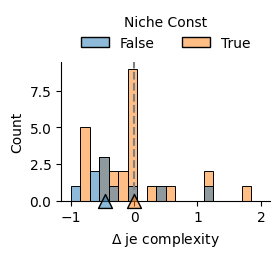

n Series: 40  n rows: 32000
['none', 'self']
Categories (2, object): ['none', 'self']


MannwhitneyuResult(statistic=193.5, pvalue=0.17746263276140262)

teeplots/2026-10-10-nicheconst-complexitystability-9s/other=none+stat=count+viz=subplots+what=self-adaptation+xlim=narrow+ext=.pdf
teeplots/2026-10-10-nicheconst-complexitystability-9s/other=none+stat=count+viz=subplots+what=self-adaptation+xlim=narrow+ext=.png


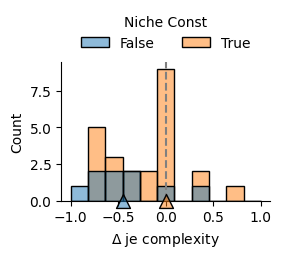

n Series: 40  n rows: 32000
['none', 'self']
Categories (2, object): ['none', 'self']


MannwhitneyuResult(statistic=193.5, pvalue=0.17746263276140262)

teeplots/2026-10-10-nicheconst-complexitystability-9s/other=none+stat=density+viz=subplots+what=self-adaptation+xlim=wide+ext=.pdf
teeplots/2026-10-10-nicheconst-complexitystability-9s/other=none+stat=density+viz=subplots+what=self-adaptation+xlim=wide+ext=.png


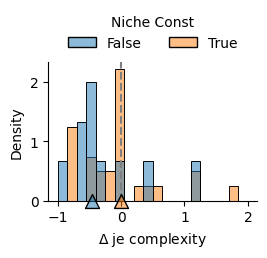

n Series: 40  n rows: 32000
['none', 'self']
Categories (2, object): ['none', 'self']


MannwhitneyuResult(statistic=193.5, pvalue=0.17746263276140262)

teeplots/2026-10-10-nicheconst-complexitystability-9s/other=none+stat=density+viz=subplots+what=self-adaptation+xlim=narrow+ext=.pdf
teeplots/2026-10-10-nicheconst-complexitystability-9s/other=none+stat=density+viz=subplots+what=self-adaptation+xlim=narrow+ext=.png


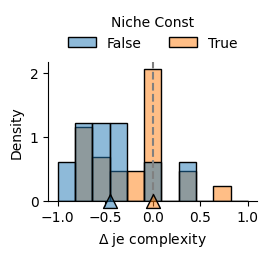

n Series: 40  n rows: 32000
['none', 'self']
Categories (2, object): ['none', 'self']


MannwhitneyuResult(statistic=173.0, pvalue=0.4733866811143227)

/usr/local/lib/python3.10/dist-packages/teeplot/teeplot.py:324: UserWarning: teeplot already created file teeplots/2026-10-10-nicheconst-complexitystability-9s/other=none+stat=count+viz=subplots+what=self-adaptation+xlim=wide+ext=.pdf, overwriting it
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/teeplot/teeplot.py:324: UserWarning: teeplot already created file teeplots/2026-10-10-nicheconst-complexitystability-9s/other=none+stat=count+viz=subplots+what=self-adaptation+xlim=wide+ext=.png, overwriting it
  warnings.warn(


teeplots/2026-10-10-nicheconst-complexitystability-9s/other=none+stat=count+viz=subplots+what=self-adaptation+xlim=wide+ext=.pdf
teeplots/2026-10-10-nicheconst-complexitystability-9s/other=none+stat=count+viz=subplots+what=self-adaptation+xlim=wide+ext=.png


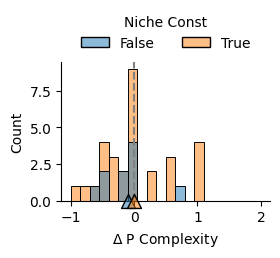

n Series: 40  n rows: 32000
['none', 'self']
Categories (2, object): ['none', 'self']


MannwhitneyuResult(statistic=173.0, pvalue=0.4733866811143227)

teeplots/2026-10-10-nicheconst-complexitystability-9s/other=none+stat=count+viz=subplots+what=self-adaptation+xlim=narrow+ext=.pdf


/usr/local/lib/python3.10/dist-packages/teeplot/teeplot.py:324: UserWarning: teeplot already created file teeplots/2026-10-10-nicheconst-complexitystability-9s/other=none+stat=count+viz=subplots+what=self-adaptation+xlim=narrow+ext=.pdf, overwriting it
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/teeplot/teeplot.py:324: UserWarning: teeplot already created file teeplots/2026-10-10-nicheconst-complexitystability-9s/other=none+stat=count+viz=subplots+what=self-adaptation+xlim=narrow+ext=.png, overwriting it
  warnings.warn(


teeplots/2026-10-10-nicheconst-complexitystability-9s/other=none+stat=count+viz=subplots+what=self-adaptation+xlim=narrow+ext=.png


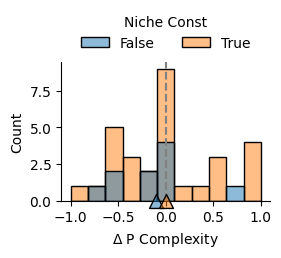

n Series: 40  n rows: 32000
['none', 'self']
Categories (2, object): ['none', 'self']


MannwhitneyuResult(statistic=173.0, pvalue=0.4733866811143227)

teeplots/2026-10-10-nicheconst-complexitystability-9s/other=none+stat=density+viz=subplots+what=self-adaptation+xlim=wide+ext=.pdf


/usr/local/lib/python3.10/dist-packages/teeplot/teeplot.py:324: UserWarning: teeplot already created file teeplots/2026-10-10-nicheconst-complexitystability-9s/other=none+stat=density+viz=subplots+what=self-adaptation+xlim=wide+ext=.pdf, overwriting it
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/teeplot/teeplot.py:324: UserWarning: teeplot already created file teeplots/2026-10-10-nicheconst-complexitystability-9s/other=none+stat=density+viz=subplots+what=self-adaptation+xlim=wide+ext=.png, overwriting it
  warnings.warn(


teeplots/2026-10-10-nicheconst-complexitystability-9s/other=none+stat=density+viz=subplots+what=self-adaptation+xlim=wide+ext=.png


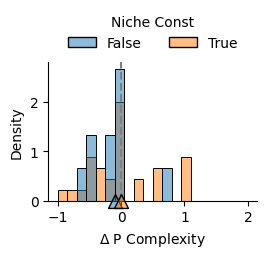

n Series: 40  n rows: 32000
['none', 'self']
Categories (2, object): ['none', 'self']


MannwhitneyuResult(statistic=173.0, pvalue=0.4733866811143227)

/usr/local/lib/python3.10/dist-packages/teeplot/teeplot.py:324: UserWarning: teeplot already created file teeplots/2026-10-10-nicheconst-complexitystability-9s/other=none+stat=density+viz=subplots+what=self-adaptation+xlim=narrow+ext=.pdf, overwriting it
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/teeplot/teeplot.py:324: UserWarning: teeplot already created file teeplots/2026-10-10-nicheconst-complexitystability-9s/other=none+stat=density+viz=subplots+what=self-adaptation+xlim=narrow+ext=.png, overwriting it
  warnings.warn(


teeplots/2026-10-10-nicheconst-complexitystability-9s/other=none+stat=density+viz=subplots+what=self-adaptation+xlim=narrow+ext=.pdf
teeplots/2026-10-10-nicheconst-complexitystability-9s/other=none+stat=density+viz=subplots+what=self-adaptation+xlim=narrow+ext=.png


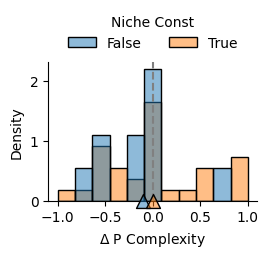

n Series: 40  n rows: 32000
['none', 'self']
Categories (2, object): ['none', 'self']


MannwhitneyuResult(statistic=184.5, pvalue=0.28813095417329293)

teeplots/2026-10-10-nicheconst-complexitystability-9s/other=none+stat=count+viz=subplots+what=self-adaptation+xlim=wide+ext=.pdf


/usr/local/lib/python3.10/dist-packages/teeplot/teeplot.py:324: UserWarning: teeplot already created file teeplots/2026-10-10-nicheconst-complexitystability-9s/other=none+stat=count+viz=subplots+what=self-adaptation+xlim=wide+ext=.pdf, overwriting it
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/teeplot/teeplot.py:324: UserWarning: teeplot already created file teeplots/2026-10-10-nicheconst-complexitystability-9s/other=none+stat=count+viz=subplots+what=self-adaptation+xlim=wide+ext=.png, overwriting it
  warnings.warn(


teeplots/2026-10-10-nicheconst-complexitystability-9s/other=none+stat=count+viz=subplots+what=self-adaptation+xlim=wide+ext=.png


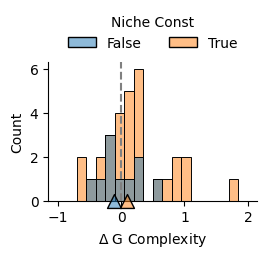

n Series: 40  n rows: 32000
['none', 'self']
Categories (2, object): ['none', 'self']


MannwhitneyuResult(statistic=184.5, pvalue=0.28813095417329293)

/usr/local/lib/python3.10/dist-packages/teeplot/teeplot.py:324: UserWarning: teeplot already created file teeplots/2026-10-10-nicheconst-complexitystability-9s/other=none+stat=count+viz=subplots+what=self-adaptation+xlim=narrow+ext=.pdf, overwriting it
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/teeplot/teeplot.py:324: UserWarning: teeplot already created file teeplots/2026-10-10-nicheconst-complexitystability-9s/other=none+stat=count+viz=subplots+what=self-adaptation+xlim=narrow+ext=.png, overwriting it
  warnings.warn(


teeplots/2026-10-10-nicheconst-complexitystability-9s/other=none+stat=count+viz=subplots+what=self-adaptation+xlim=narrow+ext=.pdf
teeplots/2026-10-10-nicheconst-complexitystability-9s/other=none+stat=count+viz=subplots+what=self-adaptation+xlim=narrow+ext=.png


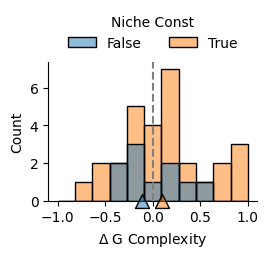

n Series: 40  n rows: 32000
['none', 'self']
Categories (2, object): ['none', 'self']


MannwhitneyuResult(statistic=184.5, pvalue=0.28813095417329293)

/usr/local/lib/python3.10/dist-packages/teeplot/teeplot.py:324: UserWarning: teeplot already created file teeplots/2026-10-10-nicheconst-complexitystability-9s/other=none+stat=density+viz=subplots+what=self-adaptation+xlim=wide+ext=.pdf, overwriting it
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/teeplot/teeplot.py:324: UserWarning: teeplot already created file teeplots/2026-10-10-nicheconst-complexitystability-9s/other=none+stat=density+viz=subplots+what=self-adaptation+xlim=wide+ext=.png, overwriting it
  warnings.warn(


teeplots/2026-10-10-nicheconst-complexitystability-9s/other=none+stat=density+viz=subplots+what=self-adaptation+xlim=wide+ext=.pdf
teeplots/2026-10-10-nicheconst-complexitystability-9s/other=none+stat=density+viz=subplots+what=self-adaptation+xlim=wide+ext=.png


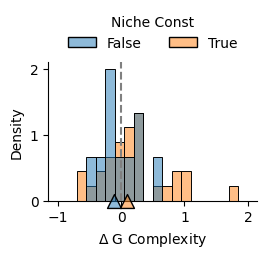

n Series: 40  n rows: 32000
['none', 'self']
Categories (2, object): ['none', 'self']


MannwhitneyuResult(statistic=184.5, pvalue=0.28813095417329293)

/usr/local/lib/python3.10/dist-packages/teeplot/teeplot.py:324: UserWarning: teeplot already created file teeplots/2026-10-10-nicheconst-complexitystability-9s/other=none+stat=density+viz=subplots+what=self-adaptation+xlim=narrow+ext=.pdf, overwriting it
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/teeplot/teeplot.py:324: UserWarning: teeplot already created file teeplots/2026-10-10-nicheconst-complexitystability-9s/other=none+stat=density+viz=subplots+what=self-adaptation+xlim=narrow+ext=.png, overwriting it
  warnings.warn(


teeplots/2026-10-10-nicheconst-complexitystability-9s/other=none+stat=density+viz=subplots+what=self-adaptation+xlim=narrow+ext=.pdf
teeplots/2026-10-10-nicheconst-complexitystability-9s/other=none+stat=density+viz=subplots+what=self-adaptation+xlim=narrow+ext=.png


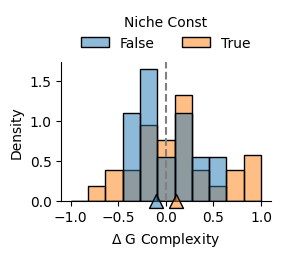

In [18]:
dfj["half"] = dfj["Stint"] > 50

dfjx = dfj[
    dfj["Stint"].isin(range(9, 101, 10))
]


dfjx["cic rank"] = dfjx["Cardinal Interface Complexity"].rank()
dfjx["fas rank"] = dfjx["Flagged Advantageous Sites"].rank()
dfjx["je"] = dfjx[["cic rank", "fas rank"]].min(axis=1)

# for other in ["eco", "none"]:
for cic, stat, xlim in it.product(
    ["je", "Cardinal Interface Complexity", "Flagged Advantageous Sites"],
    ["count", "density"],
    ["wide", "narrow"],
):
    other = "none"
    d = dfjx[
        dfjx["kind"].isin(["self", other])
    ].copy().replace({"eco": "co-evo"}).copy()
    if other == "eco":
        other = "co-evo"
    d["kind"] = pd.Categorical(
        d["kind"],
        categories=[other, "self"],
    )

    print("n Series:", d["Series"].nunique(), " n rows:", len(d))
    print(d["kind"].unique())

    dd = d.pivot_table(
        index=["Series", "Stint", cic, "half"],
        columns=["kind"],
        values=["Focal Prevalence"],
    ).reset_index()
    dd["Self Adaptation"] = dd["Focal Prevalence"]["self"] - dd["Focal Prevalence"][other]

    dd = dd.groupby(["half", "Series"]).agg(
        {
            # (cic, ""): lambda x: x.median(),
            # (cic, ""): lambda x: x.min(),
            (cic, ""): lambda x: x.nsmallest(2).max(),
            # (cic, ""): lambda x: x.nlargest(2).min(),
            # ("Self Adaptation", ""): np.median,
            ("Self Adaptation", ""): np.median,
        }
    ).reset_index(
       drop=False,
    )

    light_palette = {"self": "#6dceb1", "co-evo": "#a3cf73", "none": "#f2dfae"}
    dark_palette = {"self": "#137177", "co-evo": "#66a044", "none": "#dac796"}

    dd.sort_values(["Series", "half"], ascending=True)
    dd["diff cic"] = dd.groupby("Series")[cic].diff()
    dd["sign sa"] = dd["Self Adaptation"] > 0.0

    with tp.teed(
        plt.subplots,
        figsize=(2.7, 1.8),
        teeplot_outattrs={
            "what": "self-adaptation",
            "other": other,
            "stat": stat,
            "xlim": xlim,
        },
        teeplot_subdir=teeplot_subdir,
    ) as (fig, ax):

        ddx = dd[
            dd["half"] > 0
        ].copy()

        ddx["sign cic"] = np.sign(ddx["diff cic"])
        ddx["rel diff cic"] = ddx["diff cic"] / (ddx[cic] - ddx["diff cic"])

        # sns.boxplot(
        #     data=ddx,
        #     x="sign sa",
        #     y="rel diff cic",
        #     hue="sign sa",
        #     notch=True,
        # )
        # ax.set_ylabel(f"delta {cic}")

        display(
            scipy_stats.mannwhitneyu(
                ddx.loc[ddx["sign sa"], "rel diff cic"],
                ddx.loc[~ddx["sign sa"], "rel diff cic"],
            )
        )

        sns.histplot(
            data=ddx,
            hue="sign sa",
            x="rel diff cic",
            common_norm=False,
            stat=stat,
            ax=ax,
            binrange={"narrow": (-1, 1), "wide": (-1, 2)}[xlim],
            bins={"narrow": 11, "wide": 20}[xlim],
        )
        word = {
            "Flagged Advantageous Sites": "G Complexity",
            "Cardinal Interface Complexity": "P Complexity",
            "je": "je complexity",
        }[cic]
        ax.set_xlabel(f"$\Delta$ {word}")
        sns.move_legend(
            ax, "lower center",
            bbox_to_anchor=(.5, 1), ncol=3, title="Niche Const", frameon=False,
        )
        ax.axvline(0, ls="--", color="gray")

        sns.despine(ax=ax)

        # 1. Calculate the median of 'rel diff cic' for each 'sign sa' group
        medians = ddx.groupby("sign sa")["rel diff cic"].median()

        # 2. Safely extract the colors assigned by seaborn from the legend
        legend = ax.get_legend()
        color_map = {}
        if legend:
            for text, handle in zip(legend.texts, legend.legendHandles):
                # Histplot legend handles are usually Patches
                if hasattr(handle, 'get_facecolor'):
                    color = handle.get_facecolor()
                    # Handle edge cases where facecolor is a 2D array
                    if hasattr(color, 'ndim') and color.ndim == 2:
                        color = color[0]
                else:
                    color = "black"
                color_map[text.get_text()] = color

        # 3. Plot the triangles at the bottom of the y-axis
        y_min = ax.get_ylim()[0]
        for group_val, median_val in medians.items():
            color = color_map.get(str(group_val), "black")
            ax.scatter(
                x=median_val,
                y=y_min,
                marker="^",          # Upward-pointing triangle
                color=color,         # Match the histogram bar color
                edgecolor="black",   # Add an outline so it stands out against bars
                linewidth=1,
                s=100,               # Size of the triangle
                zorder=10,           # Ensure it draws on top of everything
                clip_on=False        # Prevent cutting off the bottom of the triangle on the axis
            )
